In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [57]:
# Загрузка данных
df = pd.read_csv('ShanghaiPM20100101_20151231.csv')

In [58]:
# Создаем столбец с датой для удобства
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)

### Шаг 1. Анализ данных

In [59]:
# 1. Изучение структуры

print("=== Структура датасета ===")
print(df.info())


=== Структура датасета ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52584 entries, 2010-01-01 00:00:00 to 2015-12-31 23:00:00
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   No             52584 non-null  int64  
 1   year           52584 non-null  int64  
 2   month          52584 non-null  int64  
 3   day            52584 non-null  int64  
 4   hour           52584 non-null  int64  
 5   season         52584 non-null  int64  
 6   PM_Jingan      24700 non-null  float64
 7   PM_US Post     34039 non-null  float64
 8   PM_Xuhui       25189 non-null  float64
 9   DEWP           52571 non-null  float64
 10  HUMI           52571 non-null  float64
 11  PRES           52556 non-null  float64
 12  TEMP           52571 non-null  float64
 13  cbwd           52572 non-null  object 
 14  Iws            52572 non-null  float64
 15  precipitation  48575 non-null  float64
 16  Iprec          48575 non-null  f

In [60]:
print("\n=== Первые 5 строк ===")
print(df.head())


=== Первые 5 строк ===
                     No  year  month  day  hour  season  PM_Jingan  \
datetime                                                             
2010-01-01 00:00:00   1  2010      1    1     0       4        NaN   
2010-01-01 01:00:00   2  2010      1    1     1       4        NaN   
2010-01-01 02:00:00   3  2010      1    1     2       4        NaN   
2010-01-01 03:00:00   4  2010      1    1     3       4        NaN   
2010-01-01 04:00:00   5  2010      1    1     4       4        NaN   

                     PM_US Post  PM_Xuhui  DEWP   HUMI    PRES  TEMP cbwd  \
datetime                                                                    
2010-01-01 00:00:00         NaN       NaN  -6.0  59.48  1026.1   1.0   cv   
2010-01-01 01:00:00         NaN       NaN  -6.0  59.48  1025.1   1.0   SE   
2010-01-01 02:00:00         NaN       NaN  -7.0  59.21  1025.1   0.0   SE   
2010-01-01 03:00:00         NaN       NaN  -6.0  63.94  1024.0   0.0   SE   
2010-01-01 04:00:00    

In [61]:
print("\n=== Пропущенные значения ===")
print(df.isnull().sum())


=== Пропущенные значения ===
No                   0
year                 0
month                0
day                  0
hour                 0
season               0
PM_Jingan        27884
PM_US Post       18545
PM_Xuhui         27395
DEWP                13
HUMI                13
PRES                28
TEMP                13
cbwd                12
Iws                 12
precipitation     4009
Iprec             4009
dtype: int64


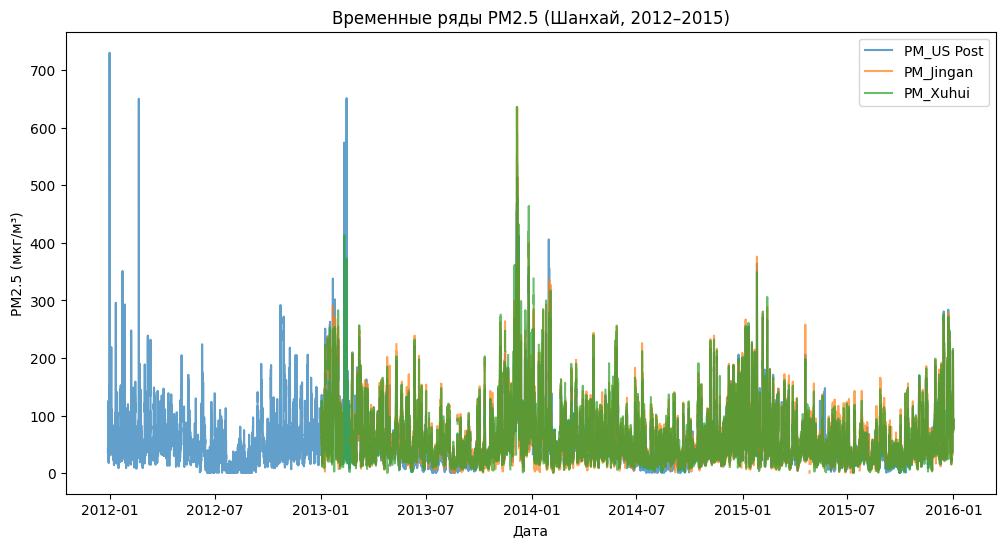

In [62]:
# 2. Визуализация временных рядов
# Графики временных рядов для PM2.5
plt.figure(figsize=(12, 6))
for col in ['PM_US Post', 'PM_Jingan', 'PM_Xuhui']:
    plt.plot(df.index, df[col], label=col, alpha=0.7)
plt.title('Временные ряды PM2.5 (Шанхай, 2012–2015)')
plt.xlabel('Дата')
plt.ylabel('PM2.5 (мкг/м³)')
plt.legend()
plt.show()

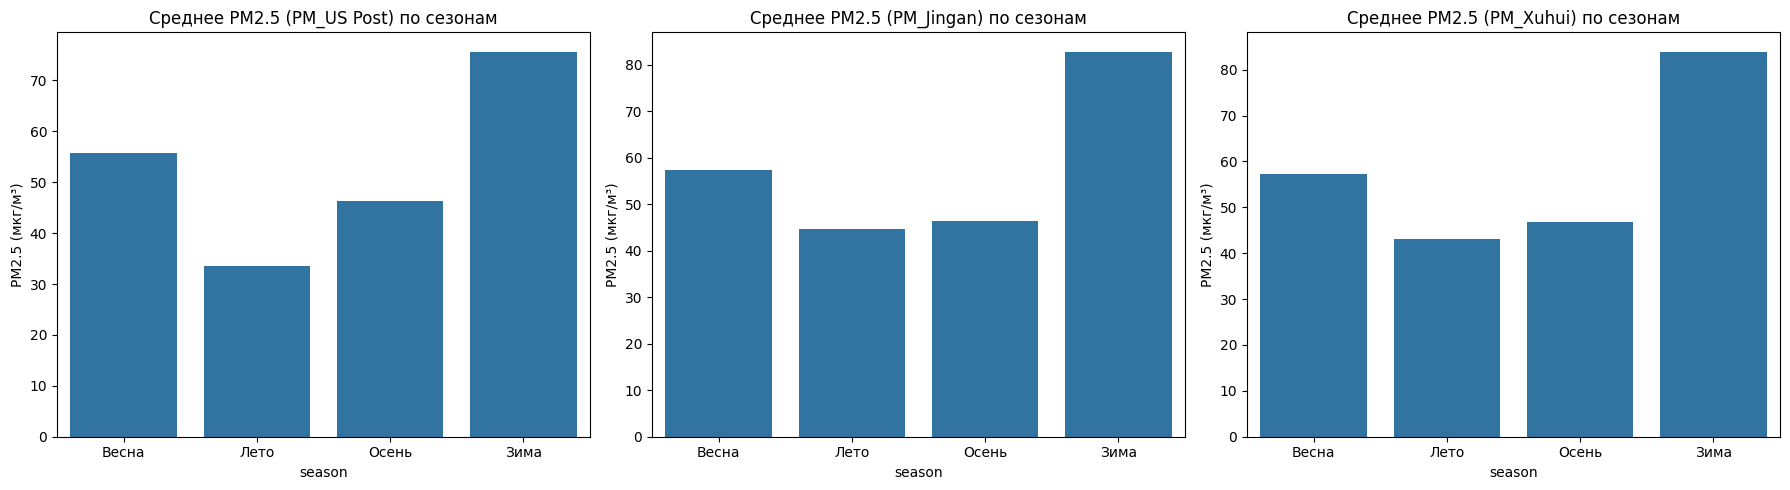

In [63]:
# Средние значения PM2.5 по сезонам
season_means = df.groupby('season')[['PM_US Post', 'PM_Jingan', 'PM_Xuhui']].mean().reset_index()
season_means['season'] = season_means['season'].map({1: 'Весна', 2: 'Лето', 3: 'Осень', 4: 'Зима'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['PM_US Post', 'PM_Jingan', 'PM_Xuhui']):
    sns.barplot(x='season', y=col, data=season_means, ax=axes[i])
    axes[i].set_title(f'Среднее PM2.5 ({col}) по сезонам')
    axes[i].set_ylabel('PM2.5 (мкг/м³)')
plt.tight_layout()
plt.show()

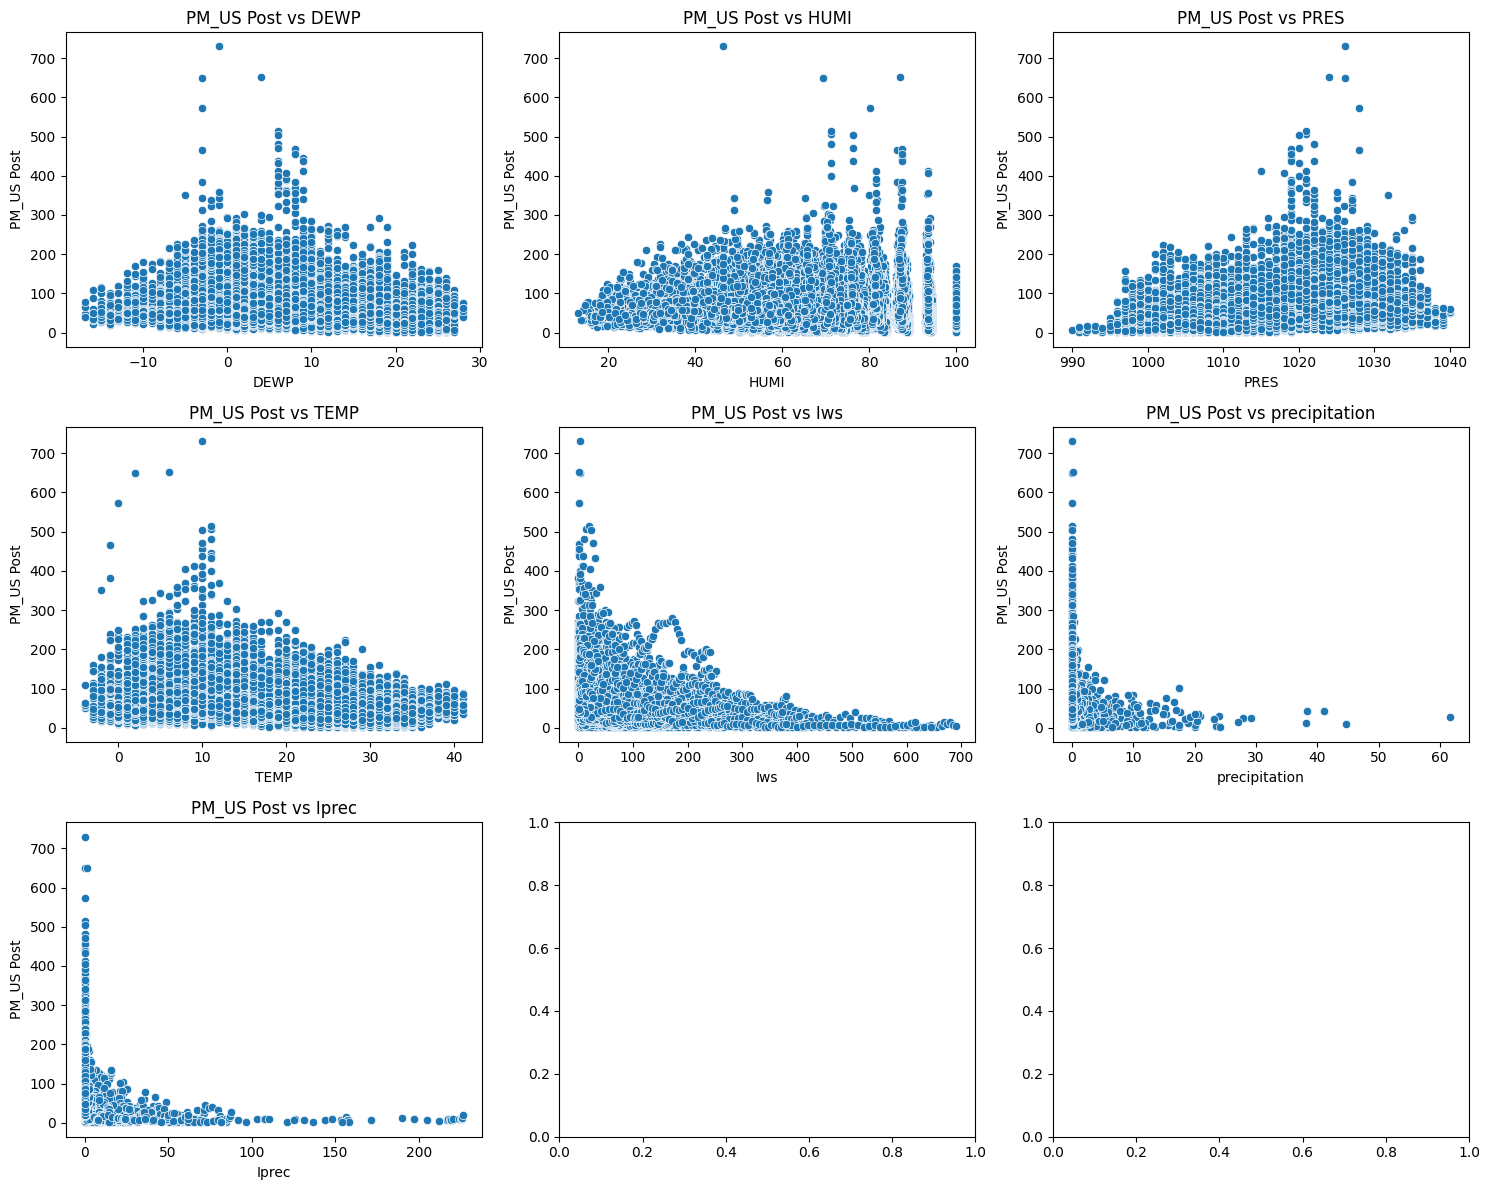

In [64]:
# 3. Анализ корреляций
# Выбираем числовые столбцы
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_df = df[num_cols]

# Scatter plots для PM_US Post и метеорологических переменных
meteo_cols = ['DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(meteo_cols):
    sns.scatterplot(x=df[col], y=df['PM_US Post'], ax=axes[i])
    axes[i].set_title(f'PM_US Post vs {col}')
fig.tight_layout()
plt.show()

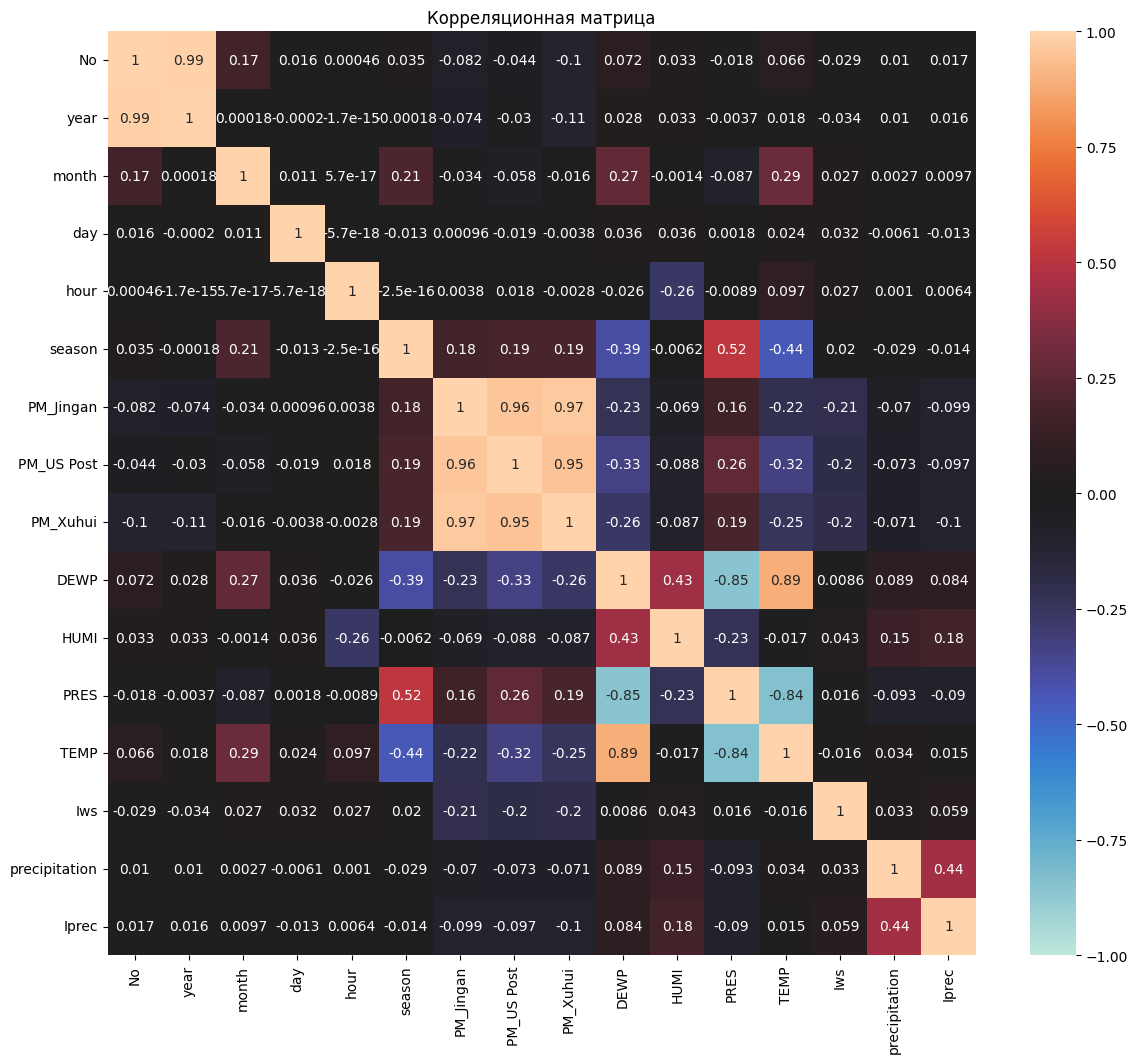

In [65]:
# Корреляционная матрица
def corrplot(df, method="pearson", annot=True, **kwargs):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        df.corr(method),
        vmin=-1.0,
        vmax=1.0,
        cmap="icefire",
        annot=annot,
        **kwargs,
    )
    plt.title("Корреляционная матрица")
    plt.show()

corrplot(num_df, annot=True)

In [66]:
# Кореляции для PM_US Post, PM_Jingan, PM_Xuhui
for target in ['PM_US Post', 'PM_Jingan', 'PM_Xuhui']:
    print(f"\nКорреляции с {target} (с направлением):")
    correlations = num_df.corr()[target].drop(target)
    print(correlations.sort_values(ascending=False))
    print(f"\nТоп-10 признаков по корреляции с {target}:")
    print(correlations.abs().sort_values(ascending=False).head(20))


Корреляции с PM_US Post (с направлением):
PM_Jingan        0.960529
PM_Xuhui         0.948877
PRES             0.263330
season           0.194385
hour             0.017788
day             -0.019010
year            -0.030007
No              -0.043969
month           -0.058360
precipitation   -0.072639
HUMI            -0.088029
Iprec           -0.097102
Iws             -0.195162
TEMP            -0.322774
DEWP            -0.331743
Name: PM_US Post, dtype: float64

Топ-10 признаков по корреляции с PM_US Post:
PM_Jingan        0.960529
PM_Xuhui         0.948877
DEWP             0.331743
TEMP             0.322774
PRES             0.263330
Iws              0.195162
season           0.194385
Iprec            0.097102
HUMI             0.088029
precipitation    0.072639
month            0.058360
No               0.043969
year             0.030007
day              0.019010
hour             0.017788
Name: PM_US Post, dtype: float64

Корреляции с PM_Jingan (с направлением):
PM_Xuhui         0.9661

In [67]:
corr_matrix = num_df.corr()
corr_pairs = corr_matrix.unstack().sort_values()

corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)] # сами с собой
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)] # зеркальные пары

top_5 = corr_pairs.tail(10)
print(top_5)

corr_count = (corr_pairs > 0.75).sum()
print(corr_count)

DEWP        month            0.267539
TEMP        month            0.291520
DEWP        HUMI             0.431864
Iprec       precipitation    0.437723
PRES        season           0.519407
DEWP        TEMP             0.890418
PM_US Post  PM_Xuhui         0.948877
PM_Jingan   PM_US Post       0.960529
            PM_Xuhui         0.966147
No          year             0.986013
dtype: float64
5


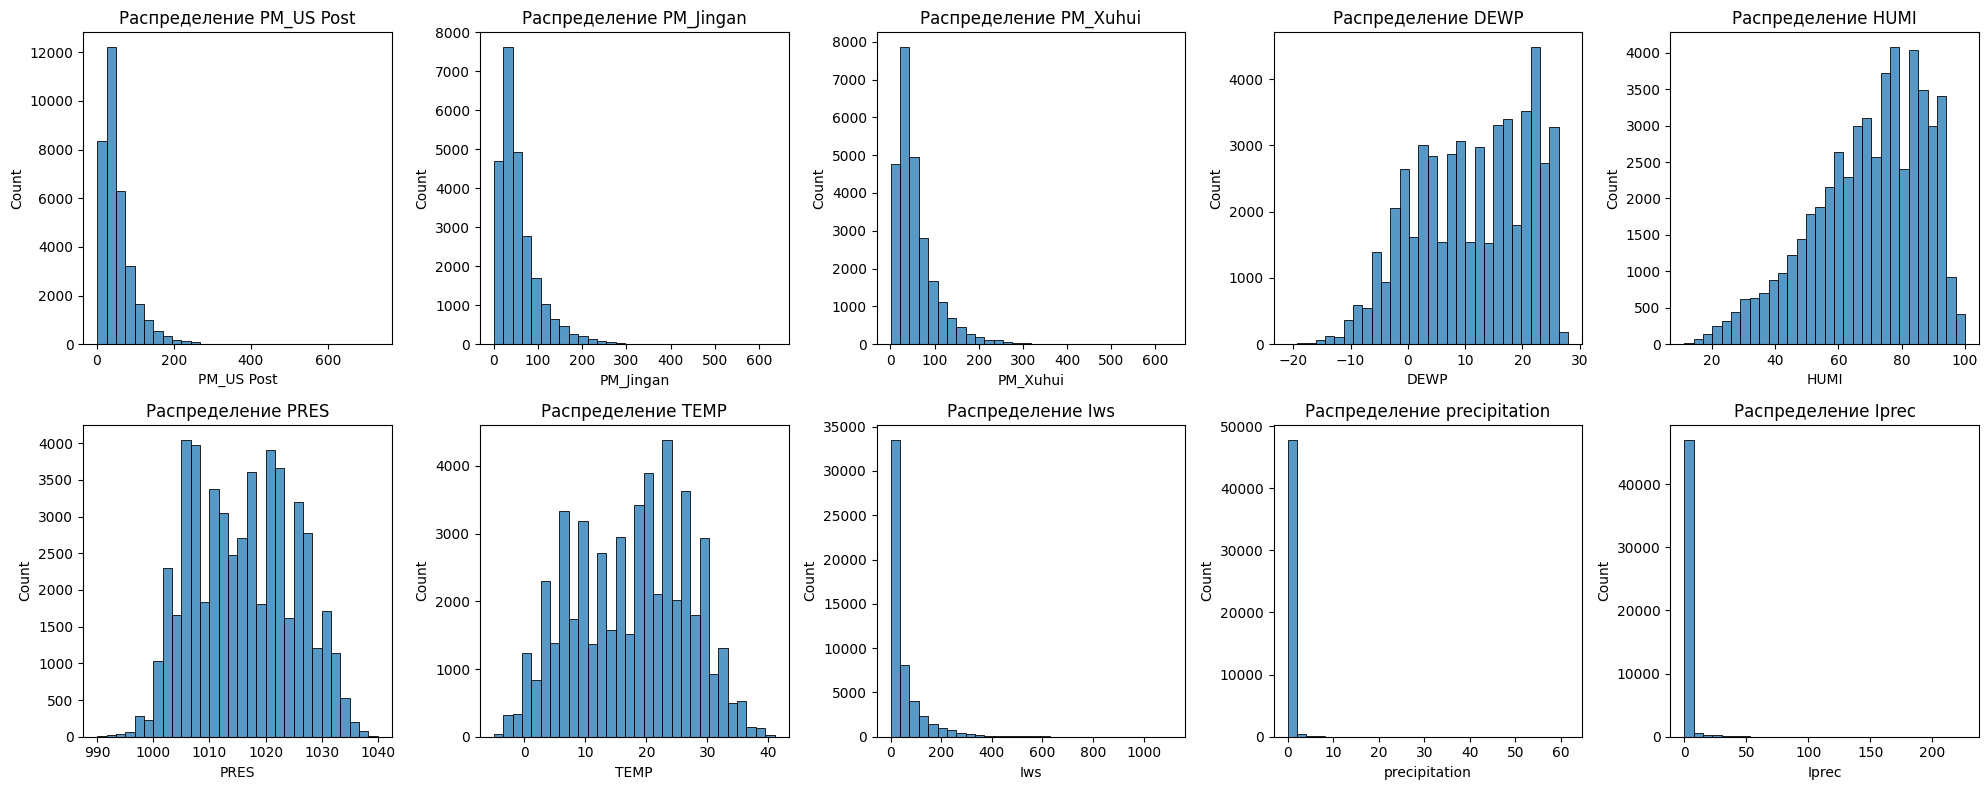

In [68]:
# 4. Распределение данных и выбросы
# Гистограммы для PM2.5 и метеорологических переменных
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
plot_cols = ['PM_US Post', 'PM_Jingan', 'PM_Xuhui', 'DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
for i, col in enumerate(plot_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

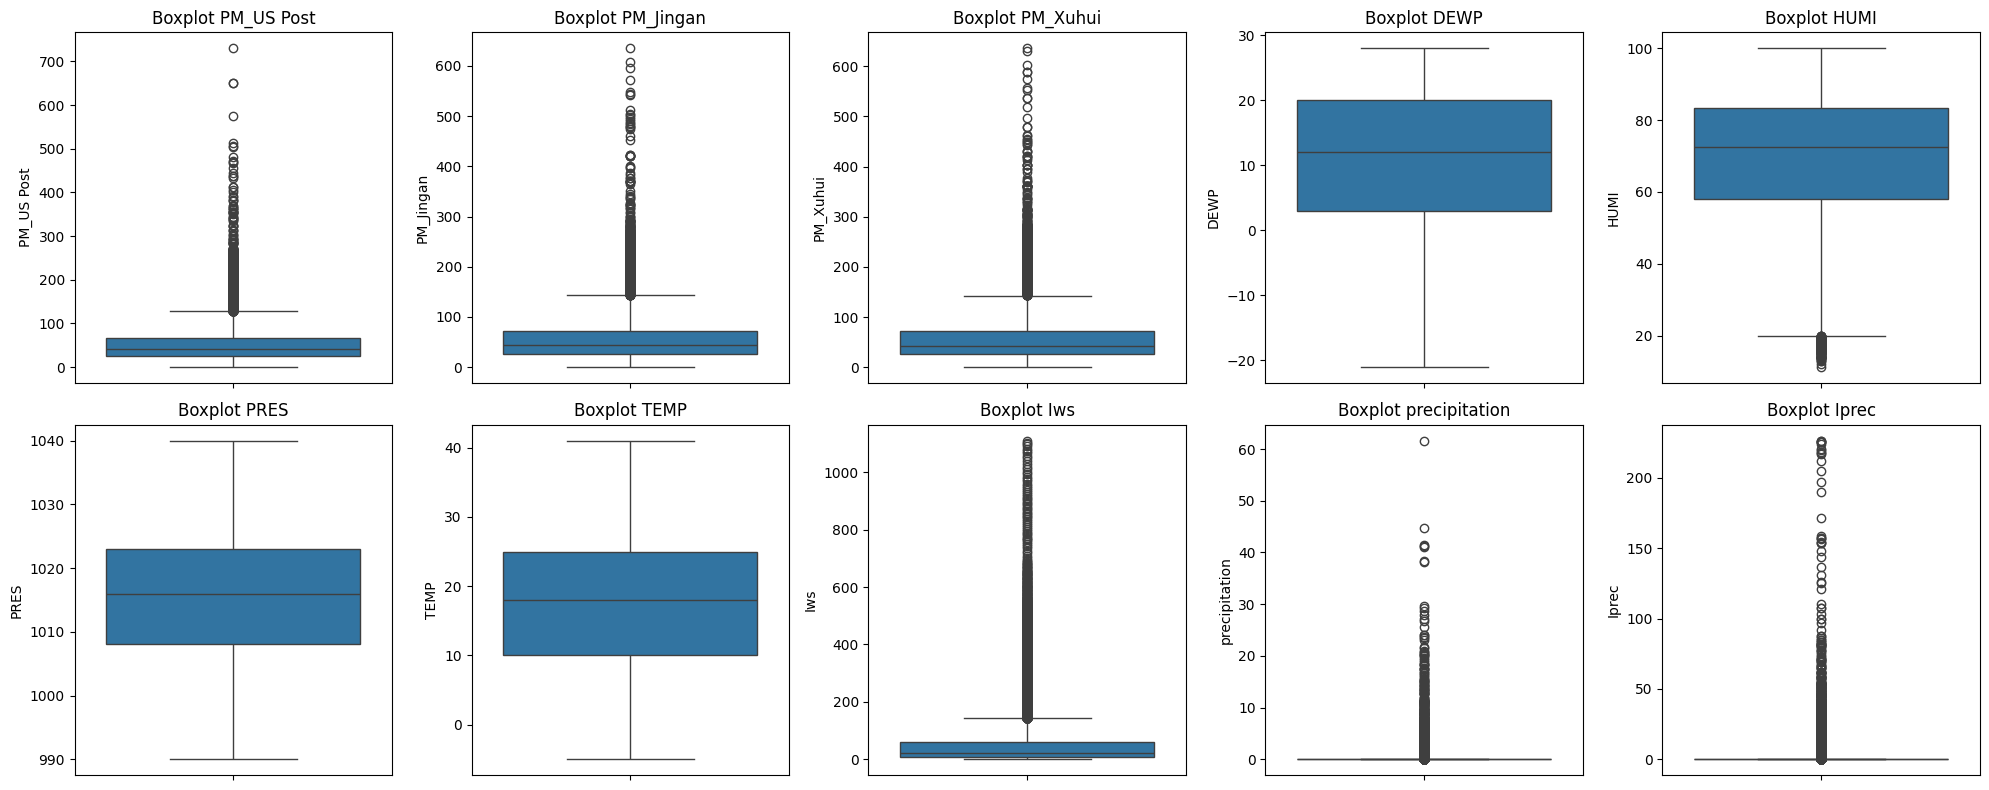

In [69]:
# Box plots для выявления выбросов
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

In [70]:
# Выявление выбросов с помощью IQR
for col in ['PM_US Post', 'PM_Jingan', 'PM_Xuhui', 'DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

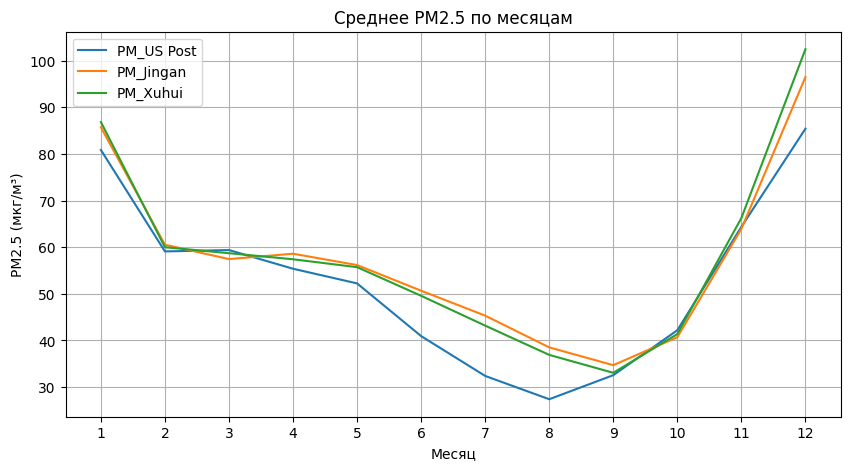

In [71]:
# 5. Средние значения PM2.5 по месяцам
monthly_means = df.groupby('month')[['PM_US Post', 'PM_Jingan', 'PM_Xuhui']].mean().reset_index()
plt.figure(figsize=(10, 5))
for col in ['PM_US Post', 'PM_Jingan', 'PM_Xuhui']:
    plt.plot(monthly_means['month'], monthly_means[col], label=col)
plt.title('Среднее PM2.5 по месяцам')
plt.xlabel('Месяц')
plt.ylabel('PM2.5 (мкг/м³)')
plt.legend()
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

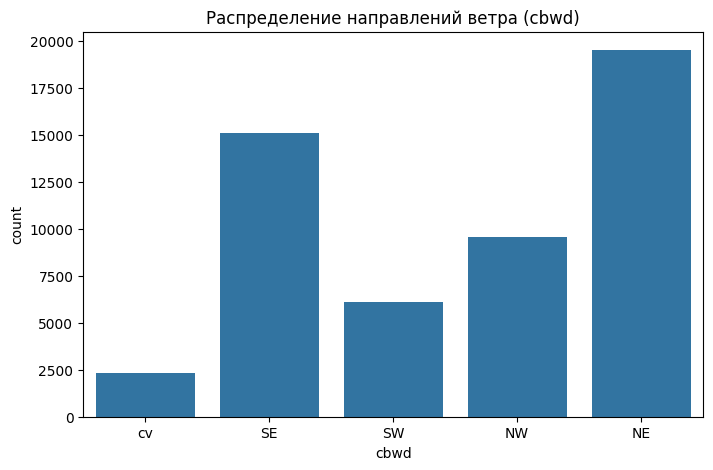

In [72]:
# 6. Анализ категориальной переменной (cbwd)
# Распределение направлений ветра
plt.figure(figsize=(8, 5))
sns.countplot(x='cbwd', data=df)
plt.title('Распределение направлений ветра (cbwd)')
plt.show()

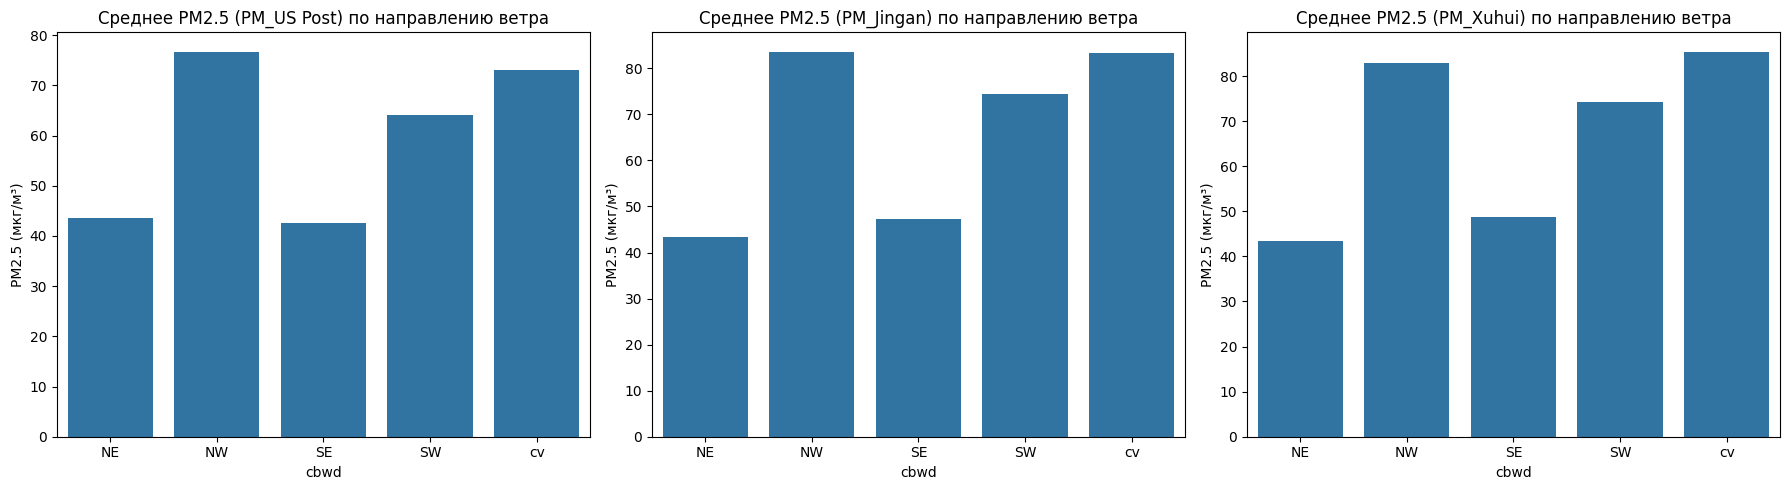

In [73]:
# Среднее PM2.5 по направлениям ветра
cbwd_means = df.groupby('cbwd')[['PM_US Post', 'PM_Jingan', 'PM_Xuhui']].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['PM_US Post', 'PM_Jingan', 'PM_Xuhui']):
    sns.barplot(x='cbwd', y=col, data=cbwd_means, ax=axes[i])
    axes[i].set_title(f'Среднее PM2.5 ({col}) по направлению ветра')
    axes[i].set_ylabel('PM2.5 (мкг/м³)')
plt.tight_layout()
plt.show()

### Шаг 2. Предобработка данных

In [74]:
# 1. Обработка пропущенных значений
numeric_cols = ['PM_Jingan', 'PM_US Post', 'PM_Xuhui', 'DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
for col in numeric_cols:
    df[col] = df[col].interpolate(method='linear')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
df['cbwd'] = df['cbwd'].fillna(df['cbwd'].mode()[0])

df = df[df.index.year >= 2012]

In [75]:
# 2. Кодирование категориальных переменных
df = pd.get_dummies(df, columns=['cbwd'], prefix='cbwd')


In [76]:
# 3. Создание временных признаков
df['day_of_week'] = df.index.dayofweek
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['season'] = ((df['month'] % 12 + 3) // 3).clip(1, 4)
season_check = (df['season'] == ((df['month'] % 12 + 3) // 3).clip(1, 4)).all()

In [77]:
# 4. Обработка выбросов
cols = ['PM_US Post', 'PM_Jingan', 'PM_Xuhui', 'DEWP', 'HUMI', 'PRES', 'TEMP']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)

# Специальная обработка для Iws с логарифмированием
if 'Iws' in df.columns:
    # Логарифмирование
    df['Iws_log'] = np.log1p(df['Iws'])
    Q1 = df['Iws_log'].quantile(0.25)
    Q3 = df['Iws_log'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(0, Q1 - 1.5 * IQR)  # Устанавливаем минимум 0 в логарифмированном масштабе
    upper_bound = Q3 + 1.5 * IQR
    df['Iws_log'] = df['Iws_log'].clip(lower_bound, upper_bound)
    # Обратное преобразование в исходный масштаб
    df['Iws'] = np.expm1(df['Iws_log'])
    df = df.drop(columns=['Iws_log'])

In [78]:
# 5. Разделение данных
train_df = df[df.index.year < 2015]
test_df = df[df.index.year == 2015]

In [79]:
# 6. Дополнительные шаги
scaler = StandardScaler()
train_numeric = train_df[numeric_cols]
test_numeric = test_df[numeric_cols]
scaler.fit(train_numeric)
train_df[numeric_cols] = scaler.transform(train_numeric)
test_df[numeric_cols] = scaler.transform(test_numeric)

train_df = train_df.drop(columns=['No'])
test_df = test_df.drop(columns=['No'])

# Сохранение данных
train_df.to_csv('train_processed.csv')
test_df.to_csv('test_processed.csv')

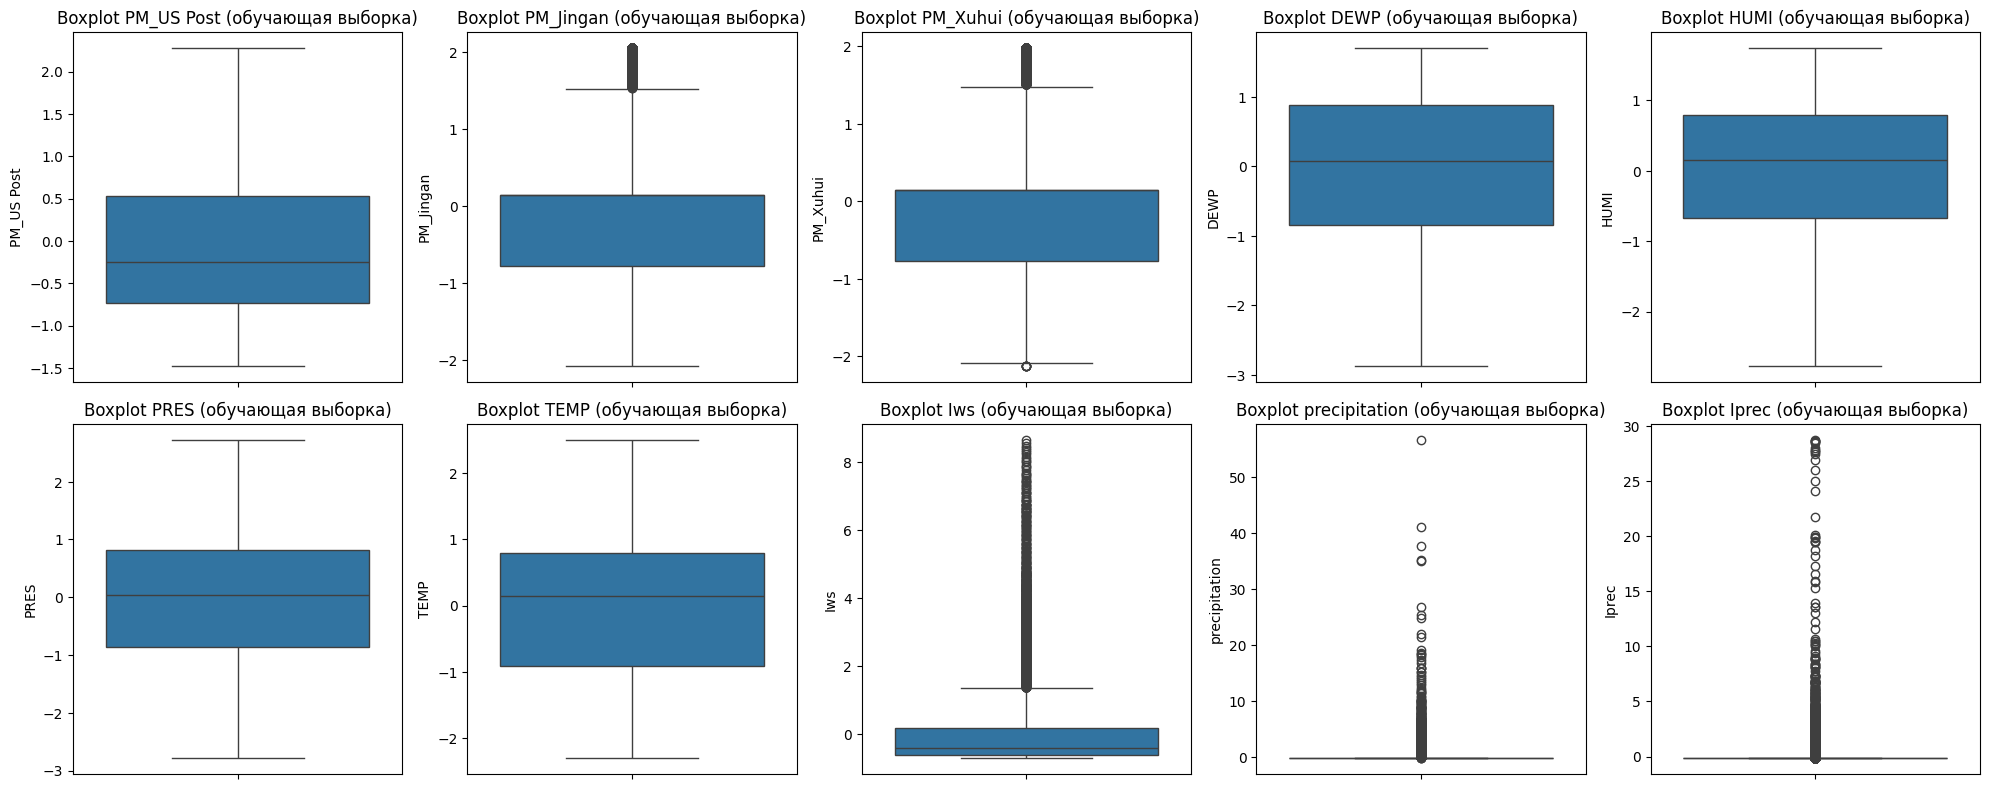

In [80]:
# 7. Boxplot для проверки выбросов
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.boxplot(y=train_df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col} (обучающая выборка)')
plt.tight_layout()
plt.show()

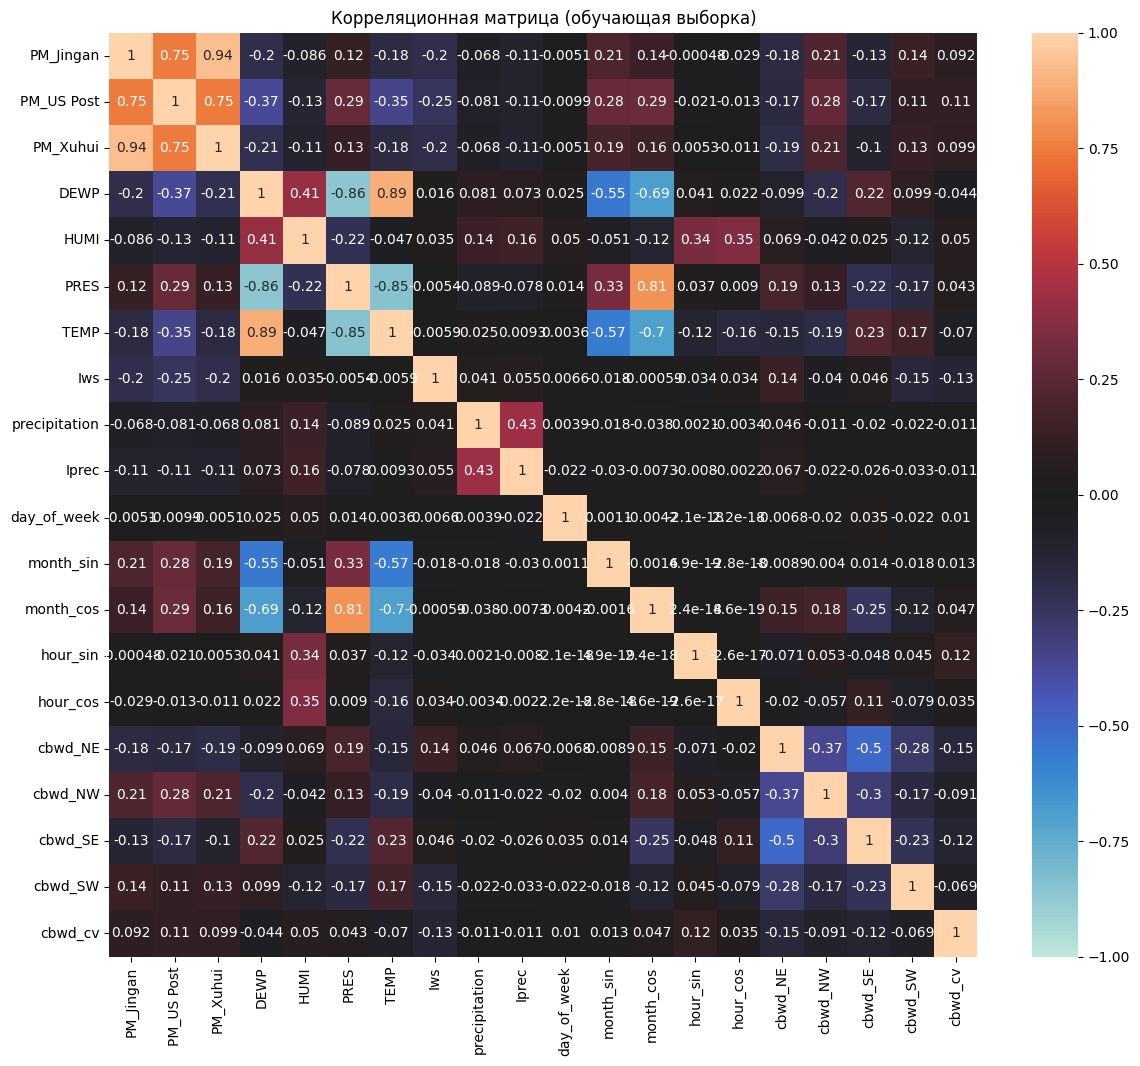

In [81]:
# 8. Корреляционная матрица после предобработки
num_cols_extended = numeric_cols + ['day_of_week', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']
corr_df = train_df[num_cols_extended + [col for col in train_df.columns if col.startswith('cbwd')]]
plt.figure(figsize=(14, 12))
sns.heatmap(corr_df.corr(), vmin=-1.0, vmax=1.0, cmap="icefire", annot=True)
plt.title("Корреляционная матрица (обучающая выборка)")
plt.show()

### Шаг 3: Инженерия признаков

In [82]:
# Загрузка предобработанных данных
train_df = pd.read_csv('train_processed.csv', index_col='datetime', parse_dates=True)
test_df = pd.read_csv('test_processed.csv', index_col='datetime', parse_dates=True)

# Объединим для инженерии признаков
df = pd.concat([train_df, test_df])

In [83]:
# 1. Лаговые признаки
# Добавляем лаги для PM2.5 за 1, 3, 6, 12, 24 часа
for col in ['PM_US Post', 'PM_Jingan', 'PM_Xuhui']:
    for lag in [1, 3, 6, 12, 24]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

In [84]:
# 2. Скользящие статистики
# Скользящее среднее и стандартное отклонение за 6 и 12 часов
for col in ['PM_US Post', 'PM_Jingan', 'PM_Xuhui', 'DEWP', 'TEMP', 'HUMI', 'PRES', 'Iws']:
    for window in [6, 12]:
        df[f'{col}_ma_{window}'] = df[col].rolling(window=window).mean()
        df[f'{col}_std_{window}'] = df[col].rolling(window=window).std()

# Заполнение пропусков после создания лагов и скользящих статистик
lag_ma_cols = [col for col in df.columns if 'lag' in col or 'ma' in col or 'std' in col]
df[lag_ma_cols] = df[lag_ma_cols].fillna(df[lag_ma_cols].median())

In [93]:
# 4. Дополнительные признаки
# Взаимодействие TEMP и HUMI
df['TEMP_HUMI_interaction'] = df['TEMP'] * df['HUMI']

df['is_winter'] = (df['season'] == 4).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

In [94]:
# Разделение обратно на train и test
train_df = df[df.index.year < 2015]
test_df = df[df.index.year == 2015]

# Для PM_US Post используем данные с 2012 года, для других станций — с 2013 года
train_df_us_post = train_df[train_df.index.year >= 2012]
train_df_other = train_df[train_df.index.year >= 2013]

# Сохранение данных с новыми признаками
train_df.to_csv('train_engineered.csv')
test_df.to_csv('test_engineered.csv')

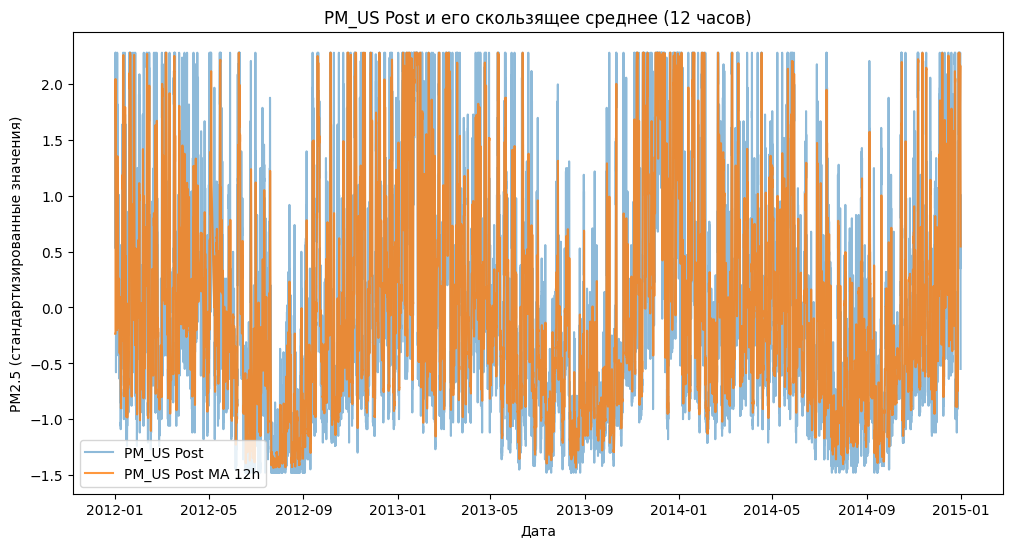

In [87]:
# 2. Влияние скользящих средних
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, train_df['PM_US Post'], label='PM_US Post', alpha=0.5)
plt.plot(train_df.index, train_df['PM_US Post_ma_12'], label='PM_US Post MA 12h', alpha=0.8)
plt.title('PM_US Post и его скользящее среднее (12 часов)')
plt.xlabel('Дата')
plt.ylabel('PM2.5 (стандартизированные значения)')
plt.legend()
plt.show()

### Шаг 4: Выбор и обучение модели

In [88]:
# Загрузка данных
train_df = pd.read_csv('train_engineered.csv', index_col='datetime', parse_dates=True)
test_df = pd.read_csv('test_engineered.csv', index_col='datetime', parse_dates=True)

# Подготовка данных с учетом разных временных диапазонов
train_df_us_post = train_df[train_df.index.year >= 2012]
train_df_other = train_df[train_df.index.year >= 2013]    

feature_cols = [col for col in train_df.columns if col not in ['PM_US Post', 'PM_Jingan', 'PM_Xuhui']]
X_test = test_df[feature_cols].values.astype(np.float32)
y_test_us_post = test_df['PM_US Post'].values.astype(np.float32)
y_test_jingan = test_df['PM_Jingan'].values.astype(np.float32)
y_test_xuhui = test_df['PM_Xuhui'].values.astype(np.float32)

In [89]:
# Шаг 5: Настройка гиперпараметров LightGBM
lgbm = LGBMRegressor(random_state=42)
param_grid = {
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 15, 20],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [20, 30, 40],
    'subsample': [0.8, 0.9, 1.0]
}
tscv = TimeSeriesSplit(n_splits=5)
random_search = RandomizedSearchCV(lgbm, param_grid, n_iter=20, cv=tscv, scoring='neg_mean_squared_error', random_state=42)

In [90]:
# Шаг 6: Финальная модель и прогнозы для всех станций
target_cols = ['PM_US Post', 'PM_Jingan', 'PM_Xuhui']
results = {}
y_pred_all = {}

for target in target_cols:
    # Выбираем соответствующий тренировочный набор
    if target == 'PM_US Post':
        train_subset = train_df_us_post
    else:
        train_subset = train_df_other
    
    X_train = train_subset[feature_cols].values.astype(np.float32)
    y_train = train_subset[target].values.astype(np.float32)
    
    # Обучение модели
    random_search.fit(X_train, y_train)
    lgbm_best = random_search.best_estimator_
    
    # Предсказания
    y_pred = lgbm_best.predict(X_test)
    
    # Выбираем соответствующие тестовые данные
    if target == 'PM_US Post':
        y_test = y_test_us_post
    elif target == 'PM_Jingan':
        y_test = y_test_jingan
    else:
        y_test = y_test_xuhui
    
    # Метрики
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[target] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    y_pred_all[target] = y_pred

    print(f"\n=== {target} ===")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7717
[LightGBM] [Info] Number of data points in the train set: 4384, number of used features: 52
[LightGBM] [Info] Start training from score 0.113469
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005383 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7952
[LightGBM] [Info] Number of data points in the train set: 8768, number of used features: 53
[LightGBM] [Info] Start training from score -0.044941
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11659
[LightGBM] [Info] Number of data points in the train set: 13152, number of used features: 72
[LightGBM] [Info] Start tra

<Figure size 1000x600 with 0 Axes>

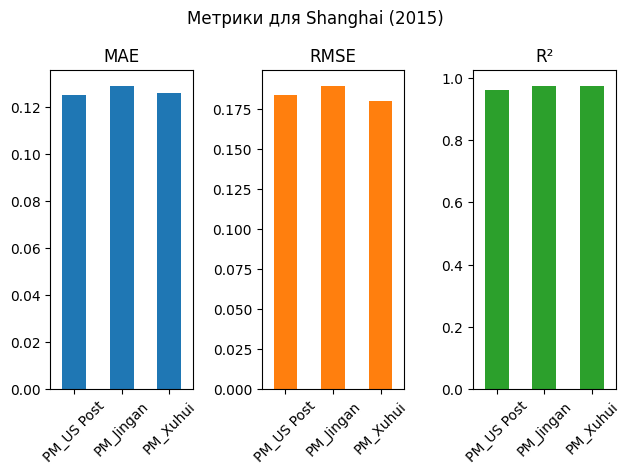


=== Отчет по Shanghai ===
PM_US Post: MAE=0.1251, RMSE=0.1834, R²=0.9606
PM_Jingan: MAE=0.1291, RMSE=0.1895, R²=0.9735
PM_Xuhui: MAE=0.1257, RMSE=0.1800, R²=0.9760


In [91]:
# Визуализация и отчет
metrics_df_shanghai = pd.DataFrame(results).T

# Визуализация метрик
plt.figure(figsize=(10, 6))
metrics_df_shanghai.plot(kind='bar', subplots=True, layout=(1, 3), 
                         title=['MAE', 'RMSE', 'R²'], 
                         legend=False, rot=45)
plt.suptitle('Метрики для Shanghai (2015)')
plt.tight_layout()
plt.show()

# Отчет
print("\n=== Отчет по Shanghai ===")
for station, metrics in results.items():
    print(f"{station}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R²={metrics['R²']:.4f}")

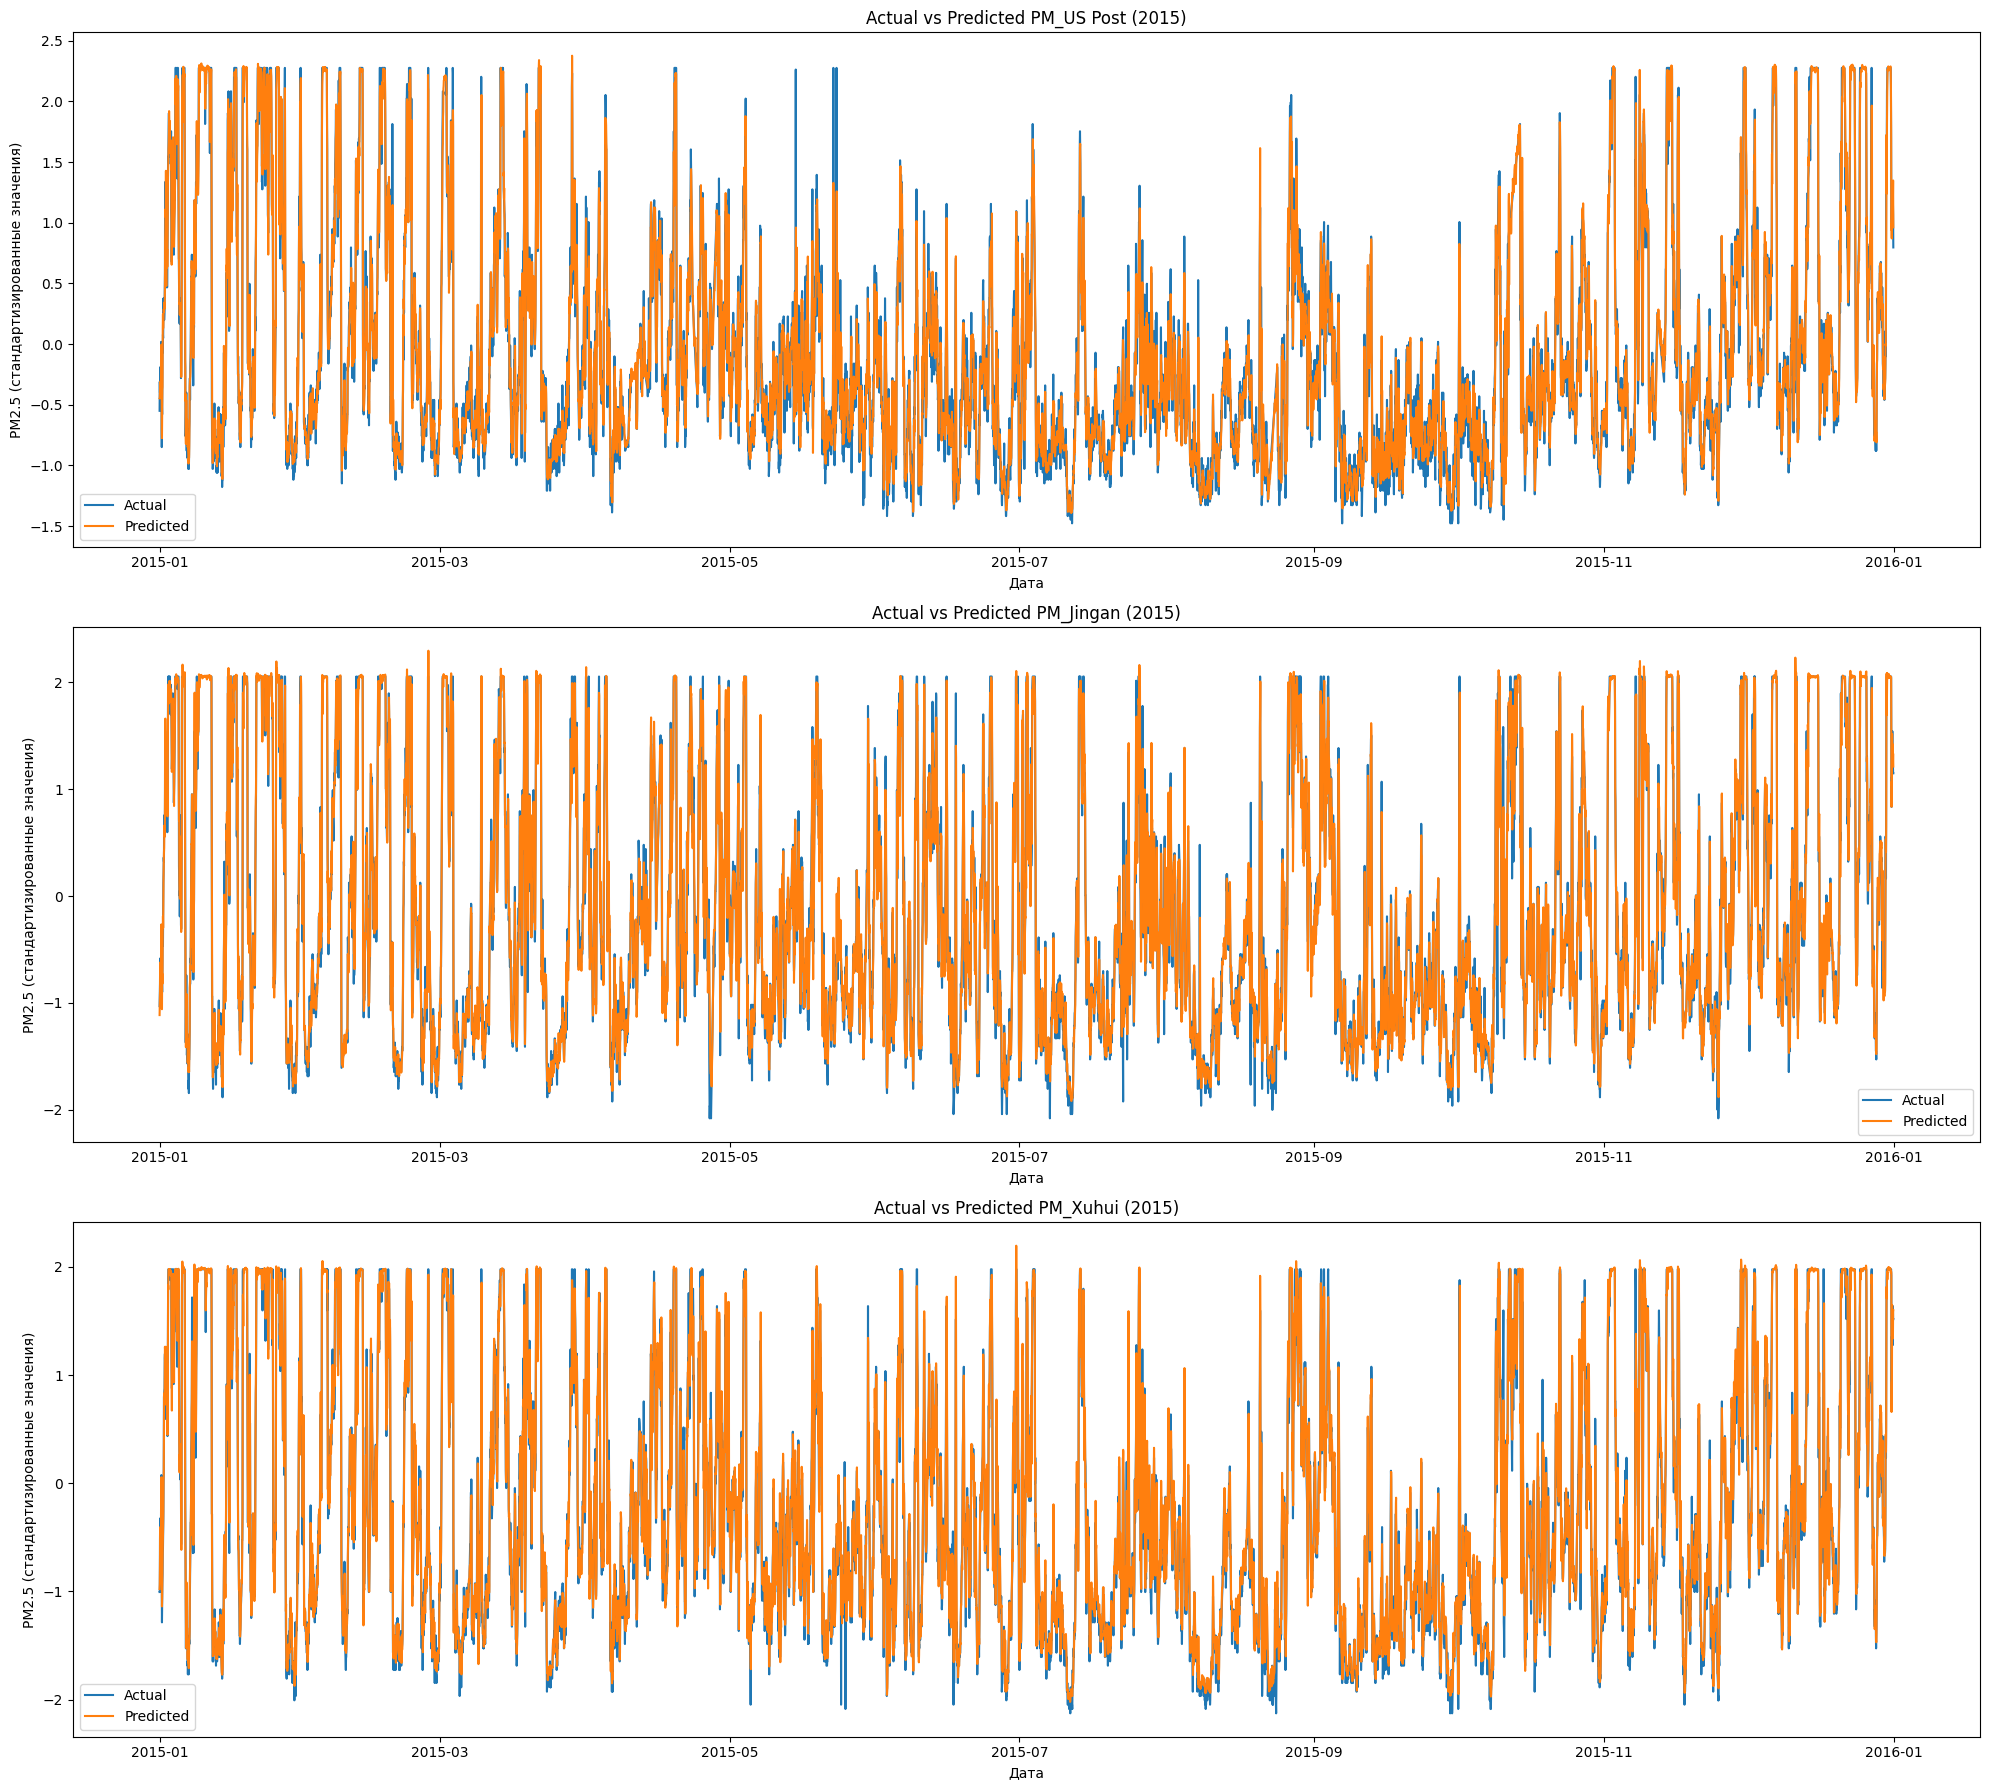

In [92]:
# Шаг 7: Визуализация и отчетность
fig, axes = plt.subplots(3, 1, figsize=(20, 18))
for i, target in enumerate(target_cols):
    axes[i].plot(test_df.index, test_df[target], label='Actual')
    axes[i].plot(test_df.index, y_pred_all[target], label='Predicted')
    axes[i].set_title(f'Actual vs Predicted {target} (2015)')
    axes[i].set_xlabel('Дата')
    axes[i].set_ylabel('PM2.5 (стандартизированные значения)')
    axes[i].legend()
plt.tight_layout()
plt.show()